# 08 — Vision Transformer (from scratch)

In [1]:
import sys
import time
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [2]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 128
BATCH_SIZE      = 64
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "vit_scratch"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [3]:
class VisionTransformer(nn.Module):
    """Minimal ViT: 16x16 patches -> CLS token -> Transformer -> classifier."""

    def __init__(self, num_classes, image_size=128, patch_size=16,
                 embed_dim=256, num_heads=8, depth=6, mlp_dim=512, dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0
        self.patch_size  = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        patch_dim        = 3 * patch_size * patch_size

        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.cls_token   = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        self.dropout     = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=mlp_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(embed_dim, num_classes))

    def forward(self, x):
        B, C, H, W = x.shape
        ps      = self.patch_size
        patches = x.unfold(2, ps, ps).unfold(3, ps, ps)
        patches = patches.contiguous().view(B, C, -1, ps, ps)
        patches = patches.permute(0, 2, 1, 3, 4).flatten(2)
        x       = self.patch_embed(patches)
        cls     = self.cls_token.expand(B, -1, -1)
        x       = torch.cat((cls, x), dim=1)
        x       = self.dropout(x + self.pos_embed)
        x       = self.transformer(x)
        return self.head(self.norm(x[:, 0]))

def create_model(num_labels):
    return VisionTransformer(num_classes=num_labels, image_size=IMAGE_SIZE)

print_model_info(create_model(NUM_LABELS))


  Total params     :    3,379,980
  Trainable params :    3,379,980  (100.0%)
  Model size       : 12.89 MB  (float32 weights)


/home/abbasidaniyal/.local/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Grid Search (LR × WD)

In [4]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4272    0.4134
  exact_match            0.0003    0.0000
  hamming_acc            0.8472    0.8532
  mean_iou               0.0027    0.0000
  precision_micro        0.1424    0.0000
  recall_micro           0.0084    0.0000
  f1_micro               0.0159    0.0000

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4160    0.4114
  exact_match            0.0003    0.0000
  hamming_acc            0.8533    0.8532
  mean_iou               0.0008    0.0000
  precision_micro        0.4545    0.0000
  recall_micro           0.0009    0.0000
  f1_micro               0.0018    0.0000

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4096    0.4032
  e

## Final Training

/home/abbasidaniyal/.local/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Epoch  1/60  [lr=2.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.5121    0.4185
  exact_match            0.0025    0.0000
  hamming_acc            0.7811    0.8532
  mean_iou               0.0389    0.0000
  precision_micro        0.1494    0.0000
  recall_micro           0.1049    0.0000
  f1_micro               0.1232    0.0000

Epoch  2/60  [lr=4.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4174    0.4160
  exact_match            0.0003    0.0000
  hamming_acc            0.8534    0.8532
  mean_iou               0.0003    0.0000
  precision_micro        1.0000    0.0000
  recall_micro           0.0002    0.0000
  f1_micro               0.0004    0.0000

Epoch  3/60  [lr=6.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4161    0.4127
  exact_match            0.0000

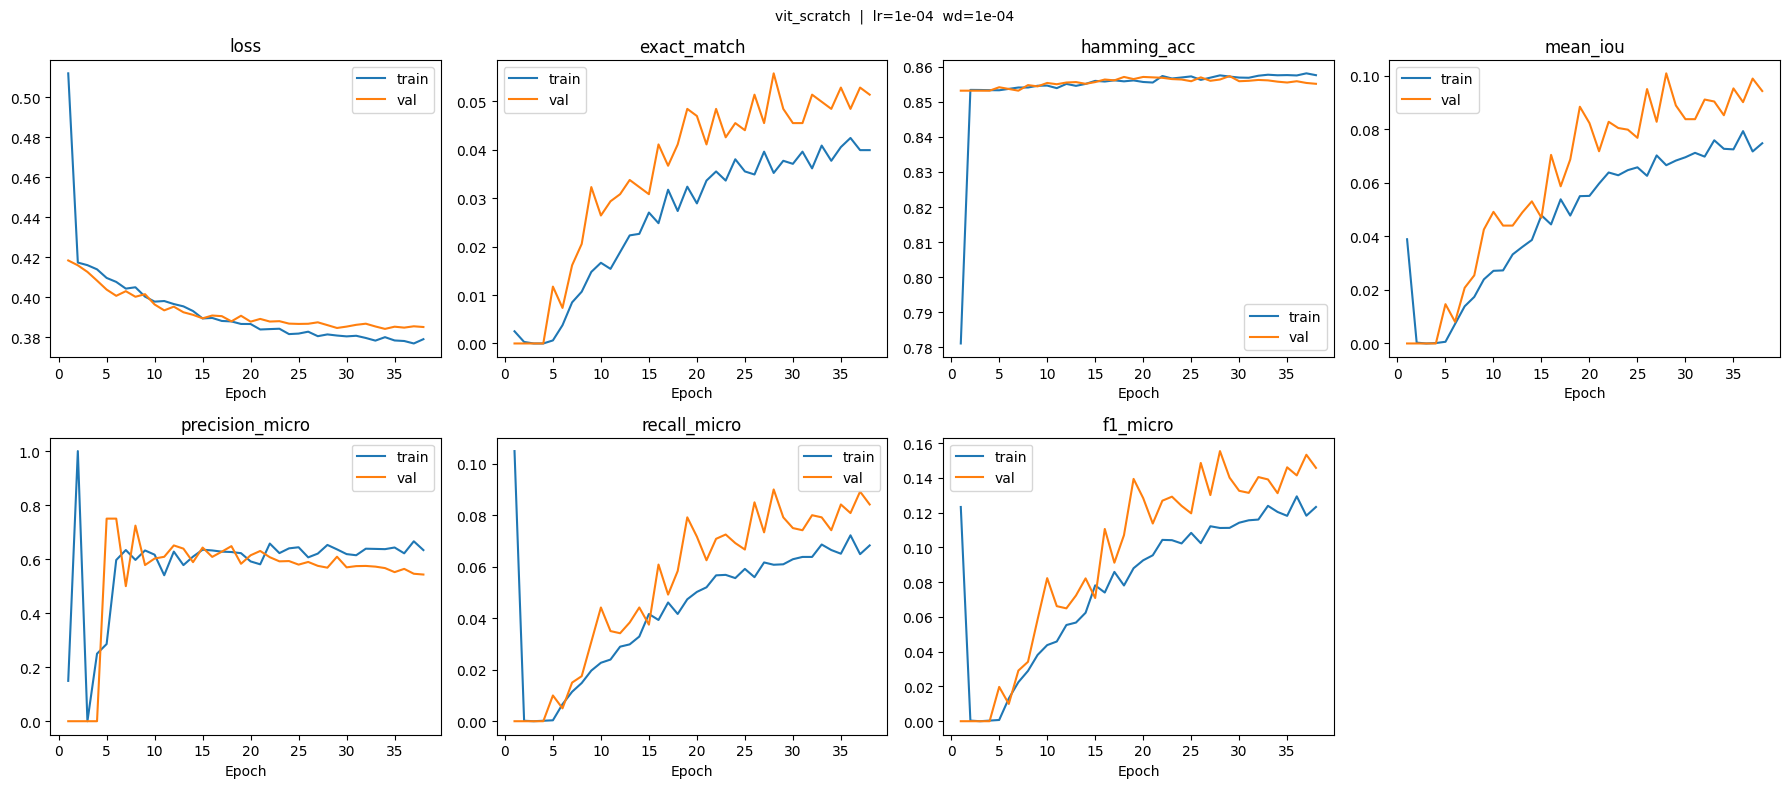

In [5]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [6]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.3861       0.0558       0.8563    0.1010           0.5684        0.0900    0.1554
test   0.3855       0.0469       0.8578    0.0955           0.5714        0.0907    0.1565


In [7]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :    3,379,980
  Trainable params :    3,379,980  (100.0%)
  Model size       : 12.89 MB  (float32 weights)
Training time : 284.0s


/home/abbasidaniyal/.local/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
